# Notebook Requirements
Run this code to execute the notebook if you didn't already cloned the repo.

In [ ]:
!git clone https://github.com/GiuseppeDaddario/Computer-Vision.git --recurse-submodules
%cd Computer-Vision

# Imports

#### Yolo + Baseline

In [ ]:
%pip install ultralytics --quiet
%pip install -U gdown

In [2]:
import os
os.environ['WANDB_MODE'] = 'disabled'
from pathlib import Path
from tqdm import tqdm
import shutil
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms,models
import torchvision.transforms as T
import torchvision.datasets as datasets
from PIL import Image
from tqdm import tqdm
from torch.utils.data import random_split
import io
#from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
#from src import YOLOv5_training, YOLOv5_inference #Importing from the yolov5 repo

### PDLPR

In [2]:
## PDLPR imports
import os
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms






import matplotlib.pyplot as plt

#Augmentation imports
from PIL import Image, ImageFilter
import torchvision.transforms.functional as TF

#Preprocessing
from torch.utils.data import random_split
import random

# Globals

### Yolo V5

In [ ]:
# -------- YOLOv5 --------- #

DATASET_PATH = "dataset/CCPD2019"
DATASET_PATH_YOLO = "dataset/CCPD2019_YOLO"
TRAINING_PATH_YOLO = "dataset/ccpd_2019.yaml"
test_dir = "ccpd_challenge"
TEST_PATH_YOLOV5 = f"dataset/CCPD_YOLO/{test_dir}/images/test" 
PROJECT_PATH = '/leonardo/home/userexternal/gdaddari/Computer-Vision/src/YOLO/runs'
YOLO_MODEL_PATH = 'src/YOLO/runs/train/weights/best.pt'

IMG_WIDTH = 720
IMG_HEIGHT = 1160
CLASS_ID = 0 
# --------------------------- #

### PDLPR

In [3]:
# -------- PDLPR --------- #

provinces = ["皖", "沪", "津", "渝", "冀", "晋", "蒙", "辽", "吉", "黑", "苏", "浙", "京", "闽","赣", "鲁", "豫", "鄂", "湘", "粤", "桂", "琼", "川", "贵", "云", "藏", "陕", "甘","青", "宁", "新", "警", "学", "O"]
alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'O']
ads = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S','T', 'U', 'V', 'W', 'X', 'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'O']

charset = provinces + [c for c in alphabets if c not in provinces] + [str(i) for i in range(10)]
charset = list(dict.fromkeys(charset))  # rimuove duplicati mantenendo l'ordine


# ------------------------ #


TRAINING_PATH_PDLPR = r"C:\Users\Lorenzo\Desktop\Computer_Vision_\dataset_cv\CCPD2019\ccpd_base"
TEST_PATH_PDLPR = r"C:\Users\Lorenzo\Desktop\Computer_Vision_\dataset_cv\CCPD2019\ccpd_challenge"
# --------------------------- #

### Baseline

In [ ]:
# -------- BASELINE --------- #

W_orig = 720
H_orig = 1160

W_resize = 224
H_resize =224

x_scale = W_resize/W_orig
y_scale = H_resize/H_orig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

provinces = ["皖", "沪", "津", "渝", "冀", "晋", "蒙", "辽", "吉", "黑", "苏", "浙", "京", "闽", "赣", "鲁", "豫", "鄂", "湘", "粤", "桂", "琼", "川", "贵", "云", "藏", "陕", "甘", "青", "宁", "新", "警", "学", "O"]
alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'O']
ads = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'O']

transform_detection = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

transform_recognition = transforms.Compose([
    transforms.Resize((64, 128)),  
    transforms.ToTensor(),
])

dataset_paths = [
    "/kaggle/input/ccpd-blur/ccpd_blur",
    "/kaggle/input/ccpd-challenge/ccpd_challenge",
    "/kaggle/input/ccpd-rotate/ccpd_rotate",
    "/kaggle/input/ccpd-db/ccpd_db",
    "/kaggle/input/ccpd-fn/ccpd_fn",
    "/kaggle/input/cppd-tilt/ccpd_tilt",
    "/kaggle/input/cppd-weather/ccpd_weather"
   
]
# --------------------------- #

# Utils

### Baseline

In [ ]:
def parse_label(filename):
        parts = filename.split('-')
        str_box = parts[2]
        x1, y1 = map(int, str_box.split('_')[0].split('A'))
        x2, y2 = map(int, str_box.split('_')[1].split('A'))
        return torch.tensor([x1, y1, x2, y2], dtype=torch.float)

def compute_iou(preds, gts):
   
    intersection_x1 = np.maximum(preds[:, 0], gts[:, 0])
    intersection_y1 = np.maximum(preds[:, 1], gts[:, 1])
    intersection_x2 = np.minimum(preds[:, 2], gts[:, 2])
    intersection_y2 = np.minimum(preds[:, 3], gts[:, 3])

    intersection_w = np.maximum(0,  intersection_x2 - intersection_x1)
    intersection_h = np.maximum(0,  intersection_y2 - intersection_y1)
    intersection_area = intersection_w * intersection_h

    area_preds = (preds[:, 2] - preds[:, 0]) * (preds[:, 3] - preds[:, 1])
    area_gts = (gts[:, 2] - gts[:, 0]) * (gts[:, 3] - gts[:, 1])

    union_area = area_preds + area_gts - intersection_area

    iou = intersection_area / (union_area + 1e-7) 

    return iou

def decode_plate(indices):
    
    indices = indices.tolist() if isinstance(indices, torch.Tensor) else indices
    return (
        provinces[indices[0]] +
        alphabets[indices[1]] +
        ''.join(ads[i] for i in indices[2:])
    )

def plot_epoch_losses(epoch_losses, title="Training Loss per Epoch"):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o', color='blue')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.xticks(range(1, len(epoch_losses)+1))
    plt.show()

### YOLOv5

In [ ]:
######################## UTILS FOR YOLOV5 ########################

def convert_bbox(x1, y1, x2, y2):
    """
    Converts bbox coordinates in pixels (normalized), following the YOLO format.
    """
    bbox_width = abs(x2 - x1)
    bbox_height = abs(y2 - y1)
    x_center = x1 + bbox_width / 2.0
    y_center = y1 + bbox_height / 2.0

    # Normalizing
    x_center /= IMG_WIDTH
    y_center /= IMG_HEIGHT
    bbox_width /= IMG_WIDTH
    bbox_height /= IMG_HEIGHT

    return x_center, y_center, bbox_width, bbox_height

def parse_filename(fname):
    """
    Extracts bbox coordinates from the image file name and converts them in YOLO format
    """
    fname = Path(fname)
    parts = fname.stem.split('-')
    if len(parts) != 7:
        return None

    try:
        bbox_str = parts[2]
        x1y1_str, x2y2_str = bbox_str.split('_')
        x1, y1 = map(int, x1y1_str.split('&'))
        x2, y2 = map(int, x2y2_str.split('&'))

        return convert_bbox(x1, y1, x2, y2)
    except Exception as e:
        print(f"[WARN] Could not parse bbox from file '{fname}': {e}")
        return None

def process_single_image(args):
    img_path, images_dest, labels_dest = args
    bbox = parse_filename(img_path.name)
    if bbox is None:
        return

    shutil.copy(img_path, images_dest / img_path.name)
    label_path = labels_dest / (img_path.stem + ".txt")
    with open(label_path, 'w') as f:
        f.write(f"{CLASS_ID} {' '.join(f'{x:.6f}' for x in bbox)}\n")


def process_images(images, images_src, dest_root, split, leonardo=False):
    images_dest = Path(dest_root) / "images" / split
    labels_dest = Path(dest_root) / "labels" / split
    os.makedirs(images_dest, exist_ok=True)
    os.makedirs(labels_dest, exist_ok=True)

    args_list = [(img_path, images_dest, labels_dest) for img_path in images]

    if leonardo:
        with ProcessPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
            list(tqdm(executor.map(process_single_image, args_list), total=len(args_list), desc=f"Processing {split} set"))
    else:
        for args in tqdm(args_list, desc=f"Processing {split} set"):
            process_single_image(args)

    print(f"{split} set saved to {images_dest} and {labels_dest}")


def prepare_ccpd_base(src_root, dest_root="CCPD_YOLO", split_ratio=0.8, seed=42):
    """
    Builds the training subdataset 'ccpd_base'.
    """
    src = "ccpd_base"
    images_src = Path(os.path.join(src_root, src))
    image_files = list(images_src.glob("*.jpg"))
    print(f"[INFO] Found {len(image_files)} images in {images_src}")
    random.seed(seed)
    random.shuffle(image_files)

    split_index = int(len(image_files) * split_ratio)
    train_files = image_files[:split_index]
    val_files = image_files[split_index:]

    process_images(train_files, images_src, f"{dest_root}/{src}", "train")
    process_images(val_files, images_src, f"{dest_root}/{src}", "val")

def prepare_other_subset(src_root, subset, dest_root="CCPD_YOLO"):
    """
    Builds the other subdatasets for the testing phase (individually).
    """
    images_src = Path(os.path.join(src_root, subset))
    image_files = list(images_src.glob("*.jpg"))
    process_images(image_files, images_src, f"{dest_root}/{subset}", "test")

def draw_bbox(img_path, label_path, out_path):
    """
    Plots and saves an example of boxplot extracted from the filename and superposed to the image.
    """
    with open(label_path) as f:
        _, xc, yc, w, h = map(float, f.readline().split())

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    xc, yc, w, h = xc * IMG_WIDTH, yc * IMG_HEIGHT, w * IMG_WIDTH, h * IMG_HEIGHT
    x1, y1 = xc - w/2, yc - h/2

    fig, ax = plt.subplots()
    ax.imshow(img)
    ax.add_patch(patches.Rectangle((x1, y1), w, h, edgecolor='r', facecolor='none', linewidth=2))
    ax.axis('off')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()
    print(f"Image saved in: {out_path}")
##################################################################

### PDLPR

#### Preprocessing

In [4]:
def decode_plate(plate_code):
    try:
        province = provinces[plate_code[0]]
        letter = alphabets[plate_code[1]]
        tail = ''.join(ads[i] for i in plate_code[2:])
        return province + letter + tail
    except Exception:
        return "INVALID"

def parse_filename(filename):
    parts = filename[:-4].split('-')
    plate_code = list(map(int, parts[4].split('_')))
    return decode_plate(plate_code)


def parse_box_from_filename(filename):
    # Esempio: filename = "074-153_423-245&374_263&409-..."
    parts = filename.split('-')
    box_str = parts[2]  # "245&374_263&409"
    (x1y1, x2y2) = box_str.split('_')
    x1, y1 = map(int, x1y1.split('&'))
    x2, y2 = map(int, x2y2.split('&'))
    return x1, y1, x2, y2

def crop_plate(img_path):
    img = Image.open(img_path).convert("RGB")
    filename = os.path.basename(img_path)
    x1, y1, x2, y2 = parse_box_from_filename(filename)
    # Assicurati che la bbox sia valida
    left, top = min(x1, x2), min(y1, y2)
    right, bottom = max(x1, x2), max(y1, y2)
    return img.crop((left, top, right, bottom))  # crop(topleft_x, y, bottomright_x, y)

#### Augmentation

In [5]:
class FullRobustAugmentation:
    def __init__(self):
        self.base = transforms.Compose([
            transforms.Resize((48, 144)),
            transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.3, hue=0.1),
            transforms.RandomRotation(degrees=30),
            transforms.RandomAffine(degrees=0, shear=10),
            transforms.RandomPerspective(distortion_scale=0.4, p=0.5),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        ])


       
    def __call__(self, img):
        img = self.base(img)  # geometrie e jitter

        if random.random() < 0.5:
            img = self.random_motion_blur(img)

        if random.random() < 0.5:
            factor = random.uniform(0.3, 1.8)
            img = TF.adjust_brightness(img, factor)

        if random.random() < 0.5:
            img = self.random_occlusion(img)

        if random.random() < 0.5:
            img = self.random_compression(img)

        if random.random() < 0.5:
            img = self.add_fog(img)

        return TF.to_tensor(img)


    def random_motion_blur(self, img):
        kernel_size = random.choice([5, 9, 15])
        return img.filter(ImageFilter.GaussianBlur(radius=kernel_size / 5))

    def add_fog(self, img):
        fog = Image.new("RGB", img.size, color=(200, 200, 200))
        return Image.blend(img, fog, alpha=random.uniform(0.1, 0.4))


    def random_occlusion(self, img):
        draw = img.copy()
        w, h = draw.size
        x0 = random.randint(0, w // 2)
        y0 = random.randint(0, h // 2)
        x1 = x0 + random.randint(10, 40)
        y1 = y0 + random.randint(10, 20)
        color = random.choice([(0, 0, 0), (255, 255, 255)])
        for x in range(x0, min(x1, w)):
            for y in range(y0, min(y1, h)):
                draw.putpixel((x, y), color)
        return draw

    def random_compression(self, img):
        buffer = io.BytesIO()
        quality = random.randint(10, 40)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer)


# Data

In [ ]:
SO="MacOs"
# Installing pixz for faster unxipping
if SO=="Linux":
    !apt-get update
    !apt-get install pixz
elif SO=="MacOs":
    !brew install pixz

zsh:1: command not found: apt-get


In [ ]:
# Downloading the .tar dataset and extracting it
%cd dataset
!gdown --id 1HDyFIuH65kVLtsXqxLA8gs0gJr7CRynh
!tar -I 'pixz -d' -xf CCPD2019.tar.xz

### Baseline

In [ ]:
class baseline_dataset_detection(Dataset):
    def __init__(self, img_dir, transform=None):
        self.folder = img_dir
        self.transform = transform
        self.images = [img for img in os.listdir(img_dir) if img.endswith(".jpg")]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.folder, img_name)
        image = Image.open(img_path).convert("RGB")


        box = parse_label(img_name)
        box = np.array(box, dtype=np.float32)
        scales = np.array([x_scale / W_resize, y_scale / H_resize, x_scale / W_resize, y_scale / H_resize])
        box = box*scales
        box = torch.tensor(box,dtype=torch.float32) 

        if self.transform:
            image = self.transform(image)

        return image, box

class baseline_dataset_recognition(Dataset):
   
    def __init__(self, image_dir, transform=None):
        self.folder = image_dir
        self.images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]
        img_path = os.path.join(self.folder, image_name)
        
        image = Image.open(img_path).convert('RGB')

        x1,y1,x2,y2 = parse_label(image_name)
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        image = image.crop((x1, y1, x2, y2))

        if self.transform:
            image = self.transform(image)

        lp_str = image_name.split('-')[-3]
        lp_idx = list(map(int, lp_str.split('_')))

    
        return image, torch.tensor(lp_idx)

### YOLOv5

In [9]:
print("Starting preprocessing...")
#scratch_dir = os.environ.get("SCRATCH", "/leonardo_scratch/large/userexternal/gdaddari")
#SRC_ROOT = os.path.join(scratch_dir, "dataset", "CCPD2019")
#base_dest = os.path.join(scratch_dir, "dataset", "CCPD_YOLO")

SRC_ROOT = os.path.join("dataset", "CCPD2019")
base_dest = os.path.join("dataset", "CCPD_YOLO")

other_subsets = [
    "ccpd_blur", "ccpd_challenge", "ccpd_db",
    "ccpd_fn", "ccpd_np", "ccpd_rotate", "ccpd_tilt", "ccpd_weather"
]

print("Training subset...")
prepare_ccpd_base(SRC_ROOT, dest_root=base_dest)

#print("Other subsets...")
#for subset in other_subsets:
    #print(f"Processing {subset}...")
    #prepare_other_subset(SRC_ROOT, subset, base_dest)

Starting preprocessing...
Training subset...
[INFO] Found 5 images in dataset/CCPD2019/ccpd_base


Processing train set: 100%|██████████| 4/4 [00:00<00:00, 698.96it/s]


train set saved to dataset/CCPD_YOLO/ccpd_base/images/train and dataset/CCPD_YOLO/ccpd_base/labels/train


Processing val set: 100%|██████████| 1/1 [00:00<00:00, 727.29it/s]

val set saved to dataset/CCPD_YOLO/ccpd_base/images/val and dataset/CCPD_YOLO/ccpd_base/labels/val


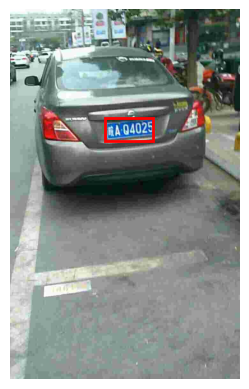

Image saved in: dataset/CCPD_YOLO/bbox-example_01-86_91-298&341_449&414-458&394_308&410_304&357_454&341-0_0_14_28_24_26_29-124-24.jpg


In [4]:
img_dir = Path("dataset/CCPD_YOLO/ccpd_base/images/train")
lbl_dir = Path("dataset/CCPD_YOLO/ccpd_base/labels/train")
out_dir = Path("dataset/CCPD_YOLO")

img = sorted(img_dir.glob("*.jpg"))[0]
lbl = lbl_dir / f"{img.stem}.txt"
out = out_dir / f"bbox-example_{img.name}"
draw_bbox(img, lbl, out)

### PDLRP

In [6]:
class CCPDPlateDataset(Dataset):
    def __init__(self, image_folder, transform=None, max_len=8):
        self.image_folder = image_folder
        self.image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]
        self.transform = transform if transform else FullRobustAugmentation()


        self.max_len = max_len
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        filename = self.image_files[idx]
        img_path = os.path.join(self.image_folder, filename)
        image = Image.open(img_path).convert("RGB")
        image = crop_plate(img_path)  # Crop the plate from the image
        image = self.transform(image)
        label_text = parse_filename(filename)
        return image, label_text

# Network

### Baseline

In [ ]:
class detection_model(nn.Module):
    
    def __init__(self, pretrained=True):
        super().__init__()
        resnet = models.resnet34(pretrained=pretrained)                

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  

        self.pool = nn.AdaptiveAvgPool2d((1, 1))  

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 4),
            nn.Sigmoid()  
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x

class recognition_model(nn.Module):
    def __init__(self, num_classes_list):
        super(recognition_model, self).__init__()
        base_model = models.resnet34(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])  
        self.classifiers = nn.ModuleList([
            nn.Linear(512, n_classes) for n_classes in num_classes_list
        ])

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        outputs = [clf(x) for clf in self.classifiers]
        return outputs

### YOLOv5

### PDLRP

In [7]:


class SimplePlateTokenizer:
    def __init__(self, charset):
        self.char2idx = {c: i + 1 for i, c in enumerate(charset)}  # 0 = PAD
        self.char2idx['<PAD>'] = 0
        self.idx2char = {i: c for c, i in self.char2idx.items()}
    def encode(self, text):
        # DEBUG: segnala caratteri non nel charset
        for c in text:
            if c not in self.char2idx:
                print(f"[Tokenizer Warning] Carattere '{c}' non nel charset! Verrà codificato come PAD (0)")
        return [self.char2idx.get(c, 0) for c in text]
    def decode(self, indices):
        return ''.join([self.idx2char.get(i, '') for i in indices if i != 0])
    def vocab_size(self):
        return len(self.char2idx)


tokenizer = SimplePlateTokenizer(charset)
num_classes = tokenizer.vocab_size()
seq_len = 8  # lunghezza massima targa CCPD





# --- IGFE ---
class FocusStructure(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.cat([
            x[..., ::2, ::2],
            x[..., 1::2, ::2],
            x[..., ::2, 1::2],
            x[..., 1::2, 1::2]
        ], dim=1)

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.leaky_relu = nn.LeakyReLU(0.2, inplace=False)
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
    def forward(self, x):
        x = self.leaky_relu(x)
        x = self.bn(x)
        x = self.conv(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.cnn_block1 = CNNBlock(in_channels, out_channels)
        self.cnn_block2 = CNNBlock(out_channels, out_channels)
        self.identity = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)
    def forward(self, x):
        identity = self.identity(x)
        out = self.cnn_block1(x)
        out = self.cnn_block2(out)
        return out + identity

class ConvDownSampling(nn.Module):
    def __init__(self, in_channels, out_channels, stride=2):
        super().__init__()
        self.leaky_relu = nn.LeakyReLU(0.2, inplace=False)
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    def forward(self, x):
        x = self.leaky_relu(x)
        x = self.bn(x)
        x = self.conv(x)
        return x

class IGFE(nn.Module):
    def __init__(self, in_channels, base_channels):
        super().__init__()
        self.focus = FocusStructure()
        self.layer1 = ResBlock(4 * in_channels, base_channels)
        self.layer2 = ResBlock(base_channels, base_channels)
        self.down1 = ConvDownSampling(base_channels, base_channels, stride=2)
        self.layer3 = ResBlock(base_channels, base_channels)
        self.layer4 = ResBlock(base_channels, base_channels)
        self.down2 = ConvDownSampling(base_channels, base_channels, stride=2)
    def forward(self, x):
        x = self.focus(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.down1(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.down2(x)
        return x





# --- Encoder ---
class PositionalEncoding2D(nn.Module):
    def __init__(self, d_model, height, width):
        super().__init__()
        if d_model % 4 != 0:
            raise ValueError("d_model must be divisible by 4 for 2D positional encoding")
        pe = torch.zeros(d_model, height, width)
        y_pos = torch.arange(0, height).unsqueeze(1).repeat(1, width)
        x_pos = torch.arange(0, width).unsqueeze(0).repeat(height, 1)
        div_term = torch.exp(torch.arange(0, d_model // 2, 2) * -(torch.log(torch.tensor(10000.0)) / (d_model // 2)))
        pe[0::4, :, :] = torch.sin(y_pos.unsqueeze(0) * div_term.unsqueeze(1).unsqueeze(2))
        pe[1::4, :, :] = torch.cos(y_pos.unsqueeze(0) * div_term.unsqueeze(1).unsqueeze(2))
        pe[2::4, :, :] = torch.sin(x_pos.unsqueeze(0) * div_term.unsqueeze(1).unsqueeze(2))
        pe[3::4, :, :] = torch.cos(x_pos.unsqueeze(0) * div_term.unsqueeze(1).unsqueeze(2))
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :x.size(2), :x.size(3)]

class EncoderModule(nn.Module):
    def __init__(self, d_model=512, nhead=8, height=16, width=16):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(d_model, height, width)
        self.cnn_block1 = CNNBlock(d_model, d_model, kernel_size=1, stride=1, padding=0)
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead)
        self.cnn_block2 = CNNBlock(d_model, d_model, kernel_size=1, stride=1, padding=0)
        self.add_norm = nn.LayerNorm(d_model)
    def forward(self, x):
        residual = x.clone()
        x = self.pos_enc(x)
        x = self.cnn_block1(x)
        B, C, H, W = x.shape
        x_ = x.permute(2, 3, 0, 1).reshape(H*W, B, C)
        attn_out, _ = self.mha(x_, x_, x_)
        x = attn_out.reshape(H, W, B, C).permute(2, 3, 0, 1)
        x = self.cnn_block2(x)
        out = residual + x
        out = out.permute(0, 2, 3, 1)
        out = self.add_norm(out)
        out = out.permute(0, 3, 1, 2)
        return out

class Encoder(nn.Module):
    def __init__(self, d_model=512, nhead=8, height=16, width=16, num_layers=3):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderModule(d_model, nhead, height, width) for _ in range(num_layers)
        ])
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x



# --- Decoder ---
class AddNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.norm = nn.LayerNorm(d_model, eps=eps)
    def forward(self, x, sublayer_out):
        return self.norm(x + sublayer_out)

class DecodingModule(nn.Module):
    def __init__(self, d_model=512, nhead=8, height=16, width=16):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(d_model, height, width)
        self.self_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead)
        self.cross_cnn1 = CNNBlock(d_model, d_model, kernel_size=1, stride=1, padding=0)
        self.cross_cnn2 = CNNBlock(d_model, d_model, kernel_size=1, stride=1, padding=0)
        self.cross_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead)
        self.feed_forward = nn.Sequential(
            nn.Conv2d(d_model, d_model * 4, kernel_size=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(d_model * 4, d_model, kernel_size=1),
        )
        self.addnorm1 = AddNorm(d_model)
        self.addnorm2 = AddNorm(d_model)
        self.addnorm3 = AddNorm(d_model)
    def forward(self, x, encoder_out):
        x = self.pos_enc(x)
        B, C, H, W = x.shape
        x_ = x.permute(2, 3, 0, 1).reshape(H*W, B, C)
        self_attn_out, _ = self.self_attn(x_, x_, x_)
        self_attn_out = self.addnorm1(x_.permute(1, 0, 2), self_attn_out.permute(1, 0, 2))
        self_attn_out = self_attn_out.permute(1, 0, 2)
        x = self_attn_out.reshape(H, W, B, C).permute(2, 3, 0, 1)
        enc = self.cross_cnn1(encoder_out)
        enc = self.cross_cnn2(enc)
        B_enc, C_enc, H_enc, W_enc = enc.shape
        enc_ = enc.permute(2, 3, 0, 1).reshape(H_enc*W_enc, B_enc, C_enc)
        x_ = x.permute(2, 3, 0, 1).reshape(H*W, B, C)
        cross_attn_out, _ = self.cross_attn(x_, enc_, enc_)
        cross_attn_out = self.addnorm2(x_.permute(1, 0, 2), cross_attn_out.permute(1, 0, 2))
        cross_attn_out = cross_attn_out.permute(1, 0, 2)
        x = cross_attn_out.reshape(H, W, B, C).permute(2, 3, 0, 1)
        ff_out = self.feed_forward(x)
        out = self.addnorm3(x.permute(0, 2, 3, 1).reshape(B, -1, C), ff_out.permute(0, 2, 3, 1).reshape(B, -1, C))
        out = out.reshape(B, H, W, C).permute(0, 3, 1, 2)
        return out

class Decoder(nn.Module):
    def __init__(self, d_model=512, nhead=8, height=16, width=16, num_layers=3, num_classes=68, seq_len=8):
        super().__init__()
        self.layers = nn.ModuleList([
            DecodingModule(d_model=d_model, nhead=nhead, height=height, width=width)
            for _ in range(num_layers)
        ])
        self.seq_len = seq_len
        self.classifier = nn.Linear(d_model, num_classes)
        self.pool = nn.AdaptiveAvgPool2d((1, seq_len))  # (B, C, 1, seq_len)
    def forward(self, x, encoder_out):
        for layer in self.layers:
            x = layer(x, encoder_out)
        x = self.pool(x)  # (B, C, 1, seq_len)
        x = x.squeeze(2)  # (B, C, seq_len)
        x = x.permute(0, 2, 1)  # (B, seq_len, C)
        logits = self.classifier(x)  # (B, seq_len, num_classes)
        return logits



## ----- FULL MODEL ----- ##
class PDLPR(nn.Module):
    def __init__(self,
                 in_channels=3,
                 base_channels=512,
                 encoder_d_model=512,
                 encoder_nhead=8,
                 encoder_height=16,
                 encoder_width=16,
                 decoder_num_layers=3,
                 num_classes=68,
                 seq_len=8):
        super().__init__()
        
        self.igfe = IGFE(in_channels, base_channels)
        
        self.pool = nn.AdaptiveAvgPool2d((encoder_height, encoder_width))
        
        self.encoder = Encoder(
            d_model=encoder_d_model, 
            nhead=encoder_nhead, 
            height=encoder_height, 
            width=encoder_width
        )
        
        
        
        self.decoder = Decoder(
            d_model=encoder_d_model,
            nhead=encoder_nhead,
            height=encoder_height,
            width=encoder_width,
            num_layers=decoder_num_layers,
            num_classes=num_classes,
            seq_len=seq_len
        )
        
    def forward(self, x):
        x = self.igfe(x)
        x = self.pool(x)
        x = self.encoder(x)
        decoder_input = torch.zeros_like(x)
        x = self.decoder(decoder_input, x)
        return x
    


def collate_fn(batch):
    images, texts = zip(*batch)
    images = torch.stack(images)
    token_seqs = [torch.tensor(tokenizer.encode(t)[:seq_len] + [0]*(seq_len-len(t))) for t in texts]
    targets = torch.stack(token_seqs)  # [B, seq_len]
    # DEBUG: controlla range target
    if (targets >= num_classes).any() or (targets < 0).any():
        print("[ERROR] Target fuori range! Ecco alcune label e codifiche:")
        for t in texts:
            print("Label:", t, "Encoded:", tokenizer.encode(t))
        print("Target tensor:", targets)
        print("num_classes:", num_classes)
        raise ValueError("Target fuori range per CrossEntropyLoss!")
    return images, targets

# Train

### Baseline

In [ ]:
#TRAINING DETECTION MODEL

number_samples =100000
num_epochs = 10


train_folder = "/kaggle/input/cppdbase/temp_rinominati"

train_dataset_detection = baseline_dataset_detection(train_folder, transform_detection)
train_dataset_detection,_ = random_split(train_dataset_detection, [number_samples,len(train_dataset_detection)-number_samples ])

train_loader_detection = DataLoader(
    train_dataset_detection,
    batch_size=32,
    shuffle=True,
    num_workers=4,  
    pin_memory=True
)

model_detection = detection_model().to(device)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model_detection.parameters(), lr=1e-3)
epoch_losses = []

for epoch in range(num_epochs):
    model_detection.train()
    epoch_loss =0
    num_batches=0
    
    for imgs,targets in tqdm(train_loader_detection, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs, targets = imgs.to(device), targets.to(device)
        preds = model_detection(imgs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1


    avg_loss = epoch_loss / num_batches
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.12f}")
plot_epoch_losses(epoch_losses)

In [ ]:
#IF YOU WANT TO SAVE THE DETECTION MODEL

torch.save(model_detection.state_dict(), "/content/drive/MyDrive/resNet34_30epoch_16batch.pth")

In [ ]:
def train_recognition(model, dataloader, criterion, optimizer, epochs=30):
    model.train()
    epoch_losses = []
    
    for epoch in range(epochs):
        
        epoch_loss=0
        num_batches = 0
        for imgs, labels in tqdm(dataloader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = sum(criterion(out, labels[:, i]) for i, out in enumerate(outputs))
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        epoch_losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.12f}")
    plot_epoch_losses(epoch_losses)  

In [ ]:
#TRAINING RECOGNITION MODEL


train_folder = "/kaggle/input/cppdbase/temp_rinominati"

train_dataset_recognition = baseline_dataset_recognition(train_folder, transform=transform_recognition)
train_loader_recognition = DataLoader(train_dataset_recognition, batch_size=32, shuffle=True)

num_classes = [len(provinces), len(alphabets)] + [len(ads)] * 5

model_recognition = recognition_model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_recognition.parameters(), lr=1e-4)

train_recognition(model_recognition, train_loader_recognition, criterion, optimizer, epochs=10)

In [ ]:
#IF YOU WANT TO SAVE THE RECOGNITION MODEL

torch.save(model_recognition.state_dict(), "/kaggle/working/model_detection.pth")

### YOLOv5

In [ ]:
# Train YOLOv5s
YOLOv5_training(
    weights="yolov5s.pt",
    data=DATASET_PATH_YOLO,
    epochs=300,
    batch_size=50,
    imgsz=640,
    optimizer="Adam",
    lr0=1e-3,
    lrf=1e-5,
    cos_lr=True,
    project="runs/train",
    name="lp_detection",
    cache="ram"
)

### PDLRP

In [ ]:
# ------ training ------ #


def PDLPR_training(image_folder,num_epochs, batch_size=32):

    # --- Training setup ---
    #image_folder = r"C:\Users\Lorenzo\Desktop\Computer_Vision_\dataset\CCPD2019\ccpd_base" 
    batch_size = 32
    dataset = CCPDPlateDataset(image_folder)

    # Suddividi il dataset in 80% train e 20% val
    train_size = int(0.8 * len(dataset)) #qua dovrei rimettere 0.8
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PDLPR(
        in_channels=3,
        base_channels=256,
        encoder_d_model=256,
        encoder_nhead=4,
        encoder_height=16,
        encoder_width=16,
        decoder_num_layers=2,
        num_classes=num_classes,
        seq_len=seq_len
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss(ignore_index=0)
    scaler = GradScaler()

    

    try:
        from tqdm import tqdm
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "tqdm"])
        from tqdm import tqdm

    train_losses = []
    val_losses = []


    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", unit="batch")
        for images, targets in pbar:
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            with autocast():
                output = model(images)
                output = output.permute(0, 2, 1)
                loss = loss_fn(output, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            pbar.set_postfix({"batch_loss": loss.item()})
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.4f}")



        
        # VALIDATION
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", unit="batch"):
                images = images.to(device)
                targets = targets.to(device)
                with autocast():
                    output = model(images)
                    output = output.permute(0, 2, 1)
                    loss = loss_fn(output, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Val Loss: {avg_val_loss:.4f}")
        

        torch.save(model.state_dict(), f"src/PDLPR/weights/pdlpr_epoch{epoch+1}.pth")
    



    torch.save(model.state_dict(), "src/PDLPR/weights/pdlpr_final.pth")


    # --- Plot delle loss ---
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss', marker='o')
    plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='x')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("src/PDLPR/logs/loss_plot.png")
    plt.close()
    print("Salvato grafico delle loss in 'src/PDLPR/loss_plot.png'")



if __name__ == "__main__":
    print("PDLPR Training ...")
    PDLPR_training(TRAINING_PATH_PDLPR, batch_size=32, num_epochs=3)

PDLPR Training ...


C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_16484\1594025806.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/3 [Train]:   0%|          | 0/5000 [00:00<?, ?batch/s]

# Evaluation

### Baseline

In [ ]:
def test_detection(model, dataset, batch_size):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    total_iou = 0.0
    well_predicted = 0
    total_samples = 0

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Testing"):
            imgs = imgs.cuda()
            preds = model(imgs).cpu().numpy()

            target_bboxes = targets.numpy()

            ious = compute_iou(preds, target_bboxes)
            total_iou += ious.sum()
            well_predicted += (ious > 0.7).sum()    
            total_samples += len(imgs)

    avg_iou = total_iou / total_samples
    print(f"\nAverage value of IoU on {total_samples} samples: {avg_iou:.4f}")
    print(f"Accuracy of well-predicted samples (IoU > 0.7): {100 * well_predicted / total_samples:.2f}%")
    print(f"Total number of samples tested: {total_samples}")

In [ ]:
# If you want to test a pre-trained model

model_detection = detection_model()  
model_detection.load_state_dict(torch.load("/kaggle/input/detection_model/pytorch/default/1/resNet34_30epoch_16batch (1).pt"))
model_detection = model_detection.to(device)

In [ ]:
for path in dataset_paths:

    print(f"\n Test on {path}")
    test_dataset_detection = baseline_dataset_detection(path, transform=transform_detection)
    test_detection(model_detection, test_dataset_detection, batch_size=16)

In [ ]:
def test_recognition(model, dataloader):
    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader):
            imgs = imgs.to(device)
            labels = labels.to(device)  

            outputs = model(imgs)  

            preds = [torch.argmax(output, dim=1) for output in outputs]  
            preds = torch.stack(preds, dim=1)  
            
            matches = (preds == labels).all(dim=1)  

            correct += matches.sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"\nTotal accuracy: {acc * 100:.2f}%")
    print(f"Total number of samples tested: {total}")

In [ ]:
#IF YOU WANT TO USE A PRE-TRAINED MODEL

num_classes = [len(provinces), len(alphabets)] + [len(ads)] * 5
model_recognition = recognition_model(num_classes)
model_recognition.load_state_dict(torch.load("/kaggle/input/recognition_model/pytorch/default/1/model_weights (1).pth"))  
model_recognition.to(device)

In [ ]:
for path in dataset_paths:
  print(f"\n Test on {path}")
  test_dataset_recognition = baseline_dataset_recognition(path, transform=transform_recognition)
  test_loader_recognition = DataLoader(test_dataset_recognition, batch_size=32, shuffle=False)
  test_recognition(model_recognition, test_loader_recognition)

In [ ]:
def complete_pipeline_test(model_detection, model_recognition, dataset_path, iou_threshold=0.6, batch_size=32):
    
    model_detection.eval()
    model_recognition.eval()

    model_detection.to(device)
    model_recognition.to(device)


    dataset = baseline_dataset_detection(dataset_path, transform=transform_detection)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


    total_images = 0
    correct_predictions = 0
    skipped_images = 0

    with torch.no_grad():
        for batch_idx, (batch_imgs, batch_true_bboxes) in enumerate(tqdm(dataloader, desc="Testing total pipeline")):
            batch_imgs = batch_imgs.to(device)
            batch_preds = model_detection(batch_imgs).cpu().numpy()
            batch_true_bboxes = batch_true_bboxes.numpy()
            batch_size_actual = batch_imgs.size(0)

             
            batch_preds[:, [0, 2]] *= W_resize
            batch_preds[:, [1, 3]] *= H_resize
            abs_true = batch_true_bboxes * np.array([W_resize, H_resize, W_resize, H_resize])

            ious = compute_iou(batch_preds, abs_true)

            for i in range(batch_size_actual):
                total_images += 1

                if ious[i] < iou_threshold:
                    skipped_images += 1
                    continue

                global_idx = batch_idx * batch_size + i
                img_path = os.path.join(dataset_path, dataset.images[global_idx])
                original_img = Image.open(img_path).convert("RGB")

                pred_bbox = batch_preds[i]
                x1, y1, x2, y2 = map(int, pred_bbox)
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(W_resize, x2), min(H_resize, y2)
                
                x1 = x1/x_scale
                y1 = y1/y_scale
                x2 = x2/x_scale
                y2 = y2/y_scale
                cropped_img = original_img.crop((x1, y1, x2, y2))
                cropped_img = transform_recognition(cropped_img).unsqueeze(0).to(device)

                outputs = model_recognition(cropped_img)
                pred = torch.stack([torch.argmax(out, dim=1) for out in outputs], dim=1).squeeze(0)

            
                filename = dataset.images[global_idx]
                label_str = filename.split('-')[-3]
                true_label = torch.tensor(list(map(int, label_str.split('_')))).to(device)

                if torch.equal(pred, true_label):
                    correct_predictions += 1

    valid_images = total_images - skipped_images
    accuracy = correct_predictions / total_images

   
    print(f"Total number of samples: {total_images}")
    print(f"Bounding box valid (IoU > {iou_threshold}): {valid_images}")
    print(f"Total number of well-predicted license plates: {correct_predictions}")
    print(f"Final accuracy: {accuracy * 100:.2f}%")

In [ ]:
#IF YOU WANT TO USE PRE-TRAINED MODELS

model_detection = detection_model()
model_detection.load_state_dict(torch.load("/kaggle/input/detection_model/pytorch/default/1/resNet34_30epoch_16batch (1).pth"))


num_classes = [len(provinces), len(alphabets)] + [len(ads)] * 5
model_recognition = recognition_model(num_classes)
model_recognition.load_state_dict(torch.load("/kaggle/input/recognition_model/pytorch/default/1/model_weights (1).pth"))  


In [ ]:
for path in dataset_paths:
   print(f"\n Test on {path}")
   complete_pipeline_test(model_detection, model_recognition, path)

### YOLOv5

In [ ]:
YOLOv5_inference(
    weights=YOLO_MODEL_PATH,
    source=TEST_PATH_YOLOV5,
    imgsz=640,
    device="cuda:0",
    project=PROJECT_PATH,
    name="test",
    exist_ok=True
)

### PDLRP

In [ ]:
# ------ inference ------ #
def PDLPR_inference(dataset_folder, batch_size=64):

    dataset = CCPDPlateDataset(dataset_folder)
    dataloader = DataLoader(dataset, batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PDLPR(
        in_channels=3,
        base_channels=256,
        encoder_d_model=256,
        encoder_nhead=4,
        encoder_height=16,
        encoder_width=16,
        decoder_num_layers=2,
        num_classes=num_classes,
        seq_len=seq_len
    ).to(device)
    model.load_state_dict(torch.load("src\PDLPR\weights\pdlpr_final.pth", map_location=device))
    model.eval()

    def decode_plate_pred(seq):
        # Rimuovi tutto dopo il primo 0 (padding)
        if 0 in seq:
            seq = seq[:seq.index(0)]
        if len(seq) > 0:
            seq = seq[:-1]  # Togli SOLO l'ultimo carattere predetto
        return tokenizer.decode(seq)

    def decode_plate_gold(seq):
        # Rimuovi tutto dopo il primo 0 (padding)
        if 0 in seq:
            seq = seq[:seq.index(0)]
        return tokenizer.decode(seq)

    correct = 0
    total = 0

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Inferenza CCPD"):
            images = images.to(device)
            outputs = model(images)  # [B, seq_len, num_classes]
            preds = outputs.argmax(dim=-1).cpu()  # [B, seq_len]
            for pred_seq, target_seq in zip(preds, targets):
                pred_plate = decode_plate_pred(pred_seq.tolist())
                gt_plate = decode_plate_gold(target_seq.tolist())
                #print(f"GT: {gt_plate} | Pred: {pred_plate}")
                if pred_plate == gt_plate:
                    correct += 1
                total += 1

    accuracy = correct / total if total > 0 else 0
    print(f"Accuracy su {total} immagini: {accuracy:.4f}")
    return accuracy




print("PDLPR Inference ...")
PDLPR_inference(TEST_PATH_PDLPR, batch_size=64)